# 07 — Entrenamiento del modelo VLA

Este notebook entrena el modelo VLA mediante **Behavioral Cloning**: aprende a imitar las acciones objetivo asociadas a los embeddings `static`, `gripper` y textual. Se usa train para actualizar los pesos y validation para seleccionar el mejor checkpoint; test se reserva para el notebook 09.

## 1. Objetivos y configuración

Se reutiliza la arquitectura de 06 y se entrena ínicamente el Transformer y el decodificador. CLIP permanece congelado porque aquí­ se utilizan sus embeddings precalculados.

In [ ]:
from pathlib import Path
import json
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

ROOT_DIR = Path(os.getcwd()).resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.project_config import PROJECT_DIR, CACHE_DIR as SHARED_CACHE_DIR, ensure_project_dirs, experiment_dirs
from src.train import load_checkpoint, train_model
from src.vla_model import VLA
from src.evaluation import evaluate_actions, benchmark_inference

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cpu')  # Configuración definida para este experimento
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EPOCHS_MAX = 25
PATIENCE = 7

CACHE_DIR = SHARED_CACHE_DIR
CHECKPOINT_PATH = ROOT_DIR / 'checkpoints' / 'vla_binary_best.pt'
RESULTS_DIR = ROOT_DIR / 'results'
FIGURES_DIR = ROOT_DIR / 'figures'
HISTORY_PATH = RESULTS_DIR / 'vla_binary_training_history.csv'
CONFIG_PATH = RESULTS_DIR / 'vla_binary_training_config.json'
LOSS_FIGURE_PATH = FIGURES_DIR / 'vla_binary_training_loss.png'
for directory in (CHECKPOINT_PATH.parent, RESULTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f'Dispositivo: {DEVICE} | semilla: {SEED}')
print(f'Batch size: {BATCH_SIZE} | Épocas máximas: {EPOCHS_MAX} | paciencia: {PATIENCE}')
# Rutas compartidas: no dependen del directorio desde el que se abra el notebook.
ROOT_DIR = PROJECT_DIR
ensure_project_dirs()

RUTAS_EXPERIMENTO = experiment_dirs('vla_binary_phase1')
CHECKPOINT_PATH = RUTAS_EXPERIMENTO['checkpoints'] / 'best.pt'
RESULTS_DIR = RUTAS_EXPERIMENTO['results']
FIGURES_DIR = RUTAS_EXPERIMENTO['figures']
HISTORY_PATH = RESULTS_DIR / 'training_history.csv'
CONFIG_PATH = RESULTS_DIR / 'training_config.json'
LOSS_FIGURE_PATH = FIGURES_DIR / 'training_loss.png'


Dispositivo: cpu | semilla: 42
Batch size: 16 | Épocas máximas: 50 | paciencia: 7


## 2. Carga de train y validation

Los `.npz` se cargan con la misma estructura de 04. Se comprueba que las entradas `static`, `gripper` y texto tienen la misma longitud, que las acciones tienen ocho componentes y que sus valores están normalizados. El archivo test no se abre ni participa en este notebook.

In [2]:
EMBEDDING_DIM = 512
OUTPUT_DIM = 8

def cargar_particion(nombre):
    ruta = CACHE_DIR / f'{nombre}.npz'
    if not ruta.exists():
        raise FileNotFoundError(f'No existe {ruta}. Ejecuta antes 04_clip_embeddings.ipynb.')
    with np.load(ruta) as datos:
        requeridas = {'imagenes_static', 'imagenes_gripper', 'textos', 'acciones'}
        if not requeridas.issubset(datos.files):
            raise KeyError(f'{nombre}: claves esperadas {requeridas}')
        static = np.asarray(datos['imagenes_static'], dtype=np.float32)
        gripper = np.asarray(datos['imagenes_gripper'], dtype=np.float32)
        textual = np.asarray(datos['textos'], dtype=np.float32)
        acciones = np.asarray(datos['acciones'], dtype=np.float32)
    if static.shape[1:] != (EMBEDDING_DIM,) or gripper.shape[1:] != (EMBEDDING_DIM,) or textual.shape[1:] != (EMBEDDING_DIM,):
        raise ValueError(f'{nombre}: embeddings con dimensiones inesperadas')
    if acciones.shape[1:] != (OUTPUT_DIM,):
        raise ValueError(f'{nombre}: acciones con dimensiones inesperadas')
    if not (len(static) == len(gripper) == len(textual) == len(acciones)):
        raise ValueError(f'{nombre}: longitudes inconsistentes')
    if not (np.isfinite(static).all() and np.isfinite(gripper).all() and np.isfinite(textual).all() and np.isfinite(acciones).all()):
        raise ValueError(f'{nombre}: hay valores no finitos')
    assert np.logical_and(acciones >= 0, acciones <= 1).all()
    return static, gripper, textual, acciones

particiones = {nombre: cargar_particion(nombre) for nombre in ('train', 'validation')}
for nombre, datos in particiones.items():
    print(f'{nombre:10s}: static={datos[0].shape}, gripper={datos[1].shape}, texto={datos[2].shape}, acciones={datos[3].shape}')

train_arrays = particiones['train']
validation_arrays = particiones['validation']
print('Test queda reservado para el notebook 09.')

train     : static=(190212, 512), gripper=(190212, 512), texto=(190212, 512), acciones=(190212, 8)
validation: static=(23760, 512), gripper=(23760, 512), texto=(23760, 512), acciones=(23760, 8)
Test queda reservado para el notebook 09.


## 3. DataLoaders y distribución de termination

Se crean lotes independientes para entrenamiento y validación. La distribución de `terminate` se muestra porque esta variable puede estar desbalanceada en una tarea robótica con pocos finales de episodio.

In [3]:
train_dataset = TensorDataset(*(torch.from_numpy(array) for array in train_arrays))
validation_dataset = TensorDataset(*(torch.from_numpy(array) for array in validation_arrays))
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

termination_values, termination_counts = np.unique(train_arrays[3][:, 0], return_counts=True)
termination_distribution = dict(zip(termination_values.astype(int).tolist(), termination_counts.tolist()))
print(f'Muestras: train={len(train_dataset):,} | validation={len(validation_dataset):,}')
print(f'Distribución train de terminate: {termination_distribution}')
batch_static, batch_gripper, batch_textual, batch_targets = next(iter(train_loader))
assert batch_targets.shape == (len(batch_targets), OUTPUT_DIM)
print(f'Lote de comprobación: static={tuple(batch_static.shape)}, gripper={tuple(batch_gripper.shape)}, texto={tuple(batch_textual.shape)} → acciones={tuple(batch_targets.shape)}')

Muestras: train=190,212 | validation=23,760
Distribución train de terminate: {0: 187330, 1: 2882}
Lote de comprobación: static=(16, 512), gripper=(16, 512), texto=(16, 512) → acciones=(16, 8)


## 4. Inicialización del modelo

El modelo se instancia desde cero. La prueba de actualización de la sección siguiente se realiza sobre una instancia temporal; después se crea una nueva instancia para garantizar que el entrenamiento no reutiliza esos pesos modificados.

In [4]:
def crear_modelo():
    # VLA recibe embeddings de CLIP ya calculados y no vuelve a procesar imágenes.
    return VLA(clip_encoder=None, embedding_dim=EMBEDDING_DIM, fusion_dim=256, decoder_hidden_dim=128).to(DEVICE)

model = crear_modelo()
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'Parámetros totales: {total_parameters:,}')
print(f'Parámetros entrenables: {trainable_parameters:,}')
assert model.clip_encoder is None  # CLIP está congelado y representado por el caché

Parámetros totales: 1,352,072
Parámetros entrenables: 1,352,072


## 5. Comprobación inicial y optimizador

Se calcula la pérdida de un lote y se comprueba que AdamW actualiza los pesos. Esta comprobación no forma parte del entrenamiento final: tras ella el modelo se reinicializa desde cero.

In [5]:
optimizer_check = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
parameter_before = next(model.parameters()).detach().clone()
optimizer_check.zero_grad(set_to_none=True)
prediction_check = model(static_embeddings=batch_static, gripper_embeddings=batch_gripper, text_embeddings=batch_textual)
from src.train import action_loss
initial_loss = action_loss(prediction_check, batch_targets)
assert torch.isfinite(initial_loss)
assert torch.all((prediction_check >= 0) & (prediction_check <= 1))
initial_loss.backward()
optimizer_check.step()
assert not torch.equal(parameter_before, next(model.parameters()).detach())
print(f'Pérdida inicial: {initial_loss.item():.6f}')
print('La actualización de prueba modificó los pesos correctamente.')

# Nueva instancia: el entrenamiento empieza sin los cambios de la comprobación.
model = crear_modelo()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

Pérdida inicial: 1.646541
La actualización de prueba modificó los pesos correctamente.


## 6. Entrenamiento con early stopping

`train_model` ejecuta una época de entrenamiento, valida una vez por época y guarda solo cuando la validation loss mejora estrictamente. El scheduler se omite según la configuración metodológica.

El historial registra por separado acciones, terminate y pinza en train y validation.

In [ ]:
config = {
    'model': 'VLA',
    'optimizer': 'AdamW',
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'batch_size': BATCH_SIZE,
    'epochs_max': EPOCHS_MAX,
    'patience': PATIENCE,
    'scheduler': None,
    'loss': 'MSE_actions + BCE_terminate + BCE_gripper',
    'inputs': ['static', 'gripper', 'texto'],
    'seed': SEED,
    'device': str(DEVICE),
    'train_samples': len(train_dataset),
    'validation_samples': len(validation_dataset),
    'trainable_parameters': trainable_parameters,
}

# Permite una prueba corta opcional; por defecto se ejecutan las 50 épocas configuradas.
epochs_to_run = int(os.environ.get('VLA_EPOCHS_OVERRIDE', EPOCHS_MAX))
summary = train_model(
    model, train_loader, validation_loader, optimizer, DEVICE,
    epochs=epochs_to_run, patience=PATIENCE,
    checkpoint_path=CHECKPOINT_PATH, config=config,
 )


Entrenamiento 1/2:   0%|          | 0/11889 [00:00<?, ?lote/s]

KeyboardInterrupt: 

In [ ]:
history = pd.DataFrame(summary['history'])
history.to_csv(HISTORY_PATH, index=False)
config.update({
    'epochs_requested': epochs_to_run,
    'epochs_executed': summary['epochs_executed'],
    'best_epoch': summary['best_epoch'],
    'best_validation_loss': summary['best_validation_loss'],
    'total_training_time_seconds': summary['total_training_time_seconds'],
    'checkpoint': str(CHECKPOINT_PATH),
    'history': str(HISTORY_PATH),
})
CONFIG_PATH.write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Épocas ejecutadas: {summary["epochs_executed"]}')
print(f'Mejor época: {summary["best_epoch"]} | validation loss: {summary["best_validation_loss"]:.6f}')
print(f'Tiempo total: {summary["total_training_time_seconds"]:.2f}s')

Épocas ejecutadas: 17
Mejor época: 10 | validation loss: 0.116132
Tiempo total: 7971.35s


## 7. Seguimiento del aprendizaje

La gráfica permite observar la evolución de train y validation loss. Una separación creciente entre ambas curvas serí­a un indicio de sobreajuste, aunque la evaluación cuantitativa queda para los notebooks posteriores.

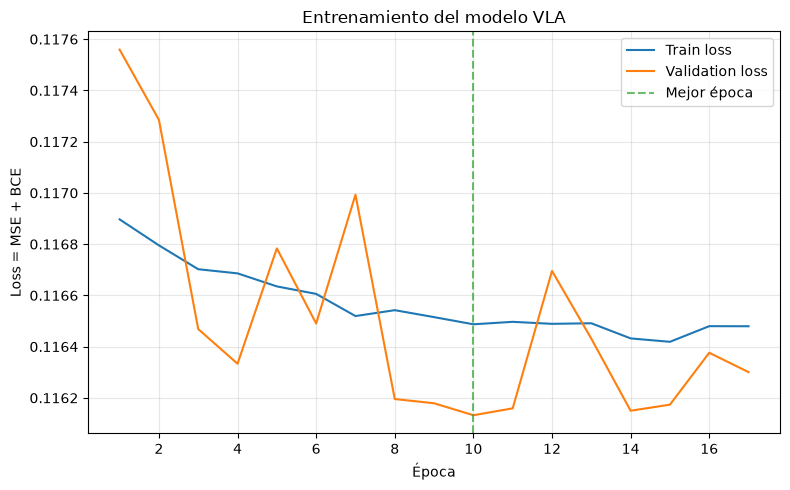

Figura guardada en C:\TFM_Codigo\TFM-VLA\figures\vla_training_loss.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_loss'], label='Train loss')
plt.plot(history['epoch'], history['validation_loss'], label='Validation loss')
plt.axvline(summary['best_epoch'], color='tab:green', linestyle='--', alpha=0.7, label='Mejor época')
plt.xlabel('Época')
plt.ylabel('Loss = MSE + BCE')
plt.title('Entrenamiento del modelo VLA')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(LOSS_FIGURE_PATH, dpi=150)
plt.show()
print(f'Figura guardada en {LOSS_FIGURE_PATH}')
plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_actions_loss'], label='Train acciones')
plt.plot(history['epoch'], history['validation_actions_loss'], label='Validation acciones')
plt.plot(history['epoch'], history['train_terminate_loss'], label='Train terminate')
plt.plot(history['epoch'], history['validation_terminate_loss'], label='Validation terminate')
plt.xlabel('época'); plt.ylabel('Pérdida'); plt.title('Pérdidas separadas del VLA'); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vla_loss_components.png', dpi=150); plt.show()


## 8. Recuperación y verificación del checkpoint

Se carga el mejor checkpoint en una instancia nueva para comprobar que el archivo es válido y conserva la época y la validation loss seleccionadas. No se evalúa test en este notebook.

In [ ]:
assert CHECKPOINT_PATH.exists()
recovered_model = crear_modelo()
recovered_optimizer = torch.optim.AdamW(recovered_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
checkpoint = load_checkpoint(CHECKPOINT_PATH, recovered_model, recovered_optimizer, map_location=DEVICE)
recovered_model.eval()
with torch.no_grad():
    recovered_predictions = recovered_model(static_embeddings=batch_static, gripper_embeddings=batch_gripper, text_embeddings=batch_textual)
assert recovered_predictions.shape == (len(batch_targets), OUTPUT_DIM)
assert torch.isfinite(recovered_predictions).all()
assert checkpoint['epoch'] == summary['best_epoch']
print(f'Checkpoint recuperado: Época {checkpoint["epoch"]}, validation loss={checkpoint["validation_loss"]:.6f}')
print('La recuperación del modelo funciona correctamente.')

Checkpoint recuperado: Época 10, validation loss=0.116132
La recuperación del modelo funciona correctamente.


### 8.1 Métricas predictivas y desequilibrio de `terminate`

Solo se evalúa validation. Se informa accuracy, F1, finalizaciones reales y predichas, junto a la referencia que siempre predice continuación.

In [ ]:
predicciones_val, objetivos_val = [], []
with torch.no_grad():
    for static, gripper, texto, objetivos in validation_loader:
        predicciones_val.append(recovered_model(static_embeddings=static.to(DEVICE), gripper_embeddings=gripper.to(DEVICE), text_embeddings=texto.to(DEVICE)).cpu())
        objetivos_val.append(objetivos)
y_pred_val, y_true_val = torch.cat(predicciones_val).numpy(), torch.cat(objetivos_val).numpy()
with (ROOT_DIR / 'data' / 'parametros_normalizacion.json').open(encoding='utf-8') as archivo:
    parametros_normalizacion = json.load(archivo)
metricas_validacion = evaluate_actions(y_pred_val, y_true_val, np.asarray(parametros_normalizacion['minimo'], dtype=np.float32), np.asarray(parametros_normalizacion['escala'], dtype=np.float32))
referencia_continuacion = {'accuracy': float((y_true_val[:, 0] == 0).mean()), 'f1': 0.0, 'real_positives': int((y_true_val[:, 0] == 1).sum()), 'predicted_positives': 0}
print('Terminate VLA:', metricas_validacion['terminate'])
print('Referencia siempre continuación:', referencia_continuacion)
print('Pinza:', metricas_validacion['gripper'])

with (RESULTS_DIR / 'vla_binary_validation_diagnostics.json').open('w', encoding='utf-8') as archivo:
    json.dump({'action_metrics': metricas_validacion, 'always_continue_reference': referencia_continuacion}, archivo, indent=2, ensure_ascii=False)


### 8.2 Eficiencia computacional

La inferencia cacheada no se compara directamente con la completa: se registran como mediciones distintas, con las mismas 32 muestras y equipo.

In [ ]:
N_MUESTRAS_TIEMPO = min(32, len(validation_arrays[0]))
static_tiempo = torch.from_numpy(validation_arrays[0][:N_MUESTRAS_TIEMPO]).to(DEVICE)
gripper_tiempo = torch.from_numpy(validation_arrays[1][:N_MUESTRAS_TIEMPO]).to(DEVICE)
texto_tiempo = torch.from_numpy(validation_arrays[2][:N_MUESTRAS_TIEMPO]).to(DEVICE)
eficiencia_cache = benchmark_inference(lambda: recovered_model(static_embeddings=static_tiempo, gripper_embeddings=gripper_tiempo, text_embeddings=texto_tiempo), N_MUESTRAS_TIEMPO)
eficiencia_cache['route'] = 'embeddings_cacheados_sin_CLIP'
from src.clip_encoder import CLIPEncoder
from src.dataset import VLADataset
particion_validacion = pd.read_parquet(ROOT_DIR / 'data' / 'procesado_clip' / 'validation.parquet').head(N_MUESTRAS_TIEMPO)
encoder_tiempo = CLIPEncoder('ViT-B-32', 'openai', DEVICE, congelar=True)
dataset_tiempo = VLADataset(particion_validacion, encoder_tiempo.preprocess, encoder_tiempo.tokenizer)
imagenes_static_tiempo, imagenes_gripper_tiempo, tokens_tiempo, _ = next(iter(DataLoader(dataset_tiempo, batch_size=N_MUESTRAS_TIEMPO, shuffle=False)))
def predecir_completo_vla():
    return recovered_model(static_embeddings=encoder_tiempo.encode_image(imagenes_static_tiempo), gripper_embeddings=encoder_tiempo.encode_image(imagenes_gripper_tiempo), text_embeddings=encoder_tiempo.encode_text(tokens_tiempo))
eficiencia_completa = benchmark_inference(predecir_completo_vla, N_MUESTRAS_TIEMPO)
eficiencia_completa['route'] = 'imagenes_static_gripper_instruccion_CLIP_y_VLA'
parametros_clip = sum(parametro.numel() for parametro in encoder_tiempo.modelo.parameters())
eficiencia_sistema = {'device': str(DEVICE), 'total_parameters_including_clip': parametros_clip + total_parameters, 'trainable_parameters': trainable_parameters, 'cached_embedding_inference': eficiencia_cache, 'full_inference_including_clip': eficiencia_completa}
print(json.dumps(eficiencia_sistema, indent=2, ensure_ascii=False))

with (RESULTS_DIR / 'vla_binary_efficiency.json').open('w', encoding='utf-8') as archivo:
    json.dump(eficiencia_sistema, archivo, indent=2, ensure_ascii=False)


## 9. Resumen final

El modelo queda preparado para los experimentos del notebook 08. El checkpoint seleccionado corresponde a la menor validation loss y el historial incluye pérdidas y tiempos de cada época ejecutada.

In [ ]:
print('Entrenamiento VLA completado.')
print(f'Mejor validation loss: {summary["best_validation_loss"]:.6f}')
print(f'Época seleccionada: {summary["best_epoch"]} / {summary["epochs_executed"]} ejecutadas')
print(f'Tiempo total: {summary["total_training_time_seconds"]:.2f} s')
print('Archivos generados:')
for ruta in (CHECKPOINT_PATH, HISTORY_PATH, CONFIG_PATH, LOSS_FIGURE_PATH):
    print(f'  - {ruta}')

Entrenamiento VLA completado.
Mejor validation loss: 0.116132
Época seleccionada: 10 / 17 ejecutadas
Tiempo total: 7971.35 s
Archivos generados:
  - C:\TFM_Codigo\TFM-VLA\checkpoints\vla_best.pt
  - C:\TFM_Codigo\TFM-VLA\results\vla_training_history.csv
  - C:\TFM_Codigo\TFM-VLA\results\vla_training_config.json
  - C:\TFM_Codigo\TFM-VLA\figures\vla_training_loss.png


## Resumen de resultados

Este notebook utiliza la configuración centralizada y entrena el VLA con las vistas `static` y `gripper` antes de los experimentos posteriores.